# Proyecto final

## Desarrollo de una herramienta analítica usando paquetes especializados para análisis de datos en Python

Para el desarrollo de este proyecto puedes utilizar cualquier librería externa. Te recomendamos leer por completo el enunciado antes de comenzar, de forma que tengas claro el propósito global de la actividad y puedas desarrollar tu solución apuntando a él desde el inicio.

Al desarrollar este proyecto pondrás a prueba tus habilidades para:

1. Identificar y abordar preguntas de negocio y de *analytics*.
2. Leer datos desde archivos y almacenarlos utilizando métodos de librerías especializadas.
3. Explorar, modificar, limpiar y unir objetos tablas de datos.
4. Implementar análisis combinando métricas descriptivas, visualización, filtrado y agrupación.
5. Implementar análisis basado en modelos estadísticos o de *machine learning*.

##  Contexto: desigualdad y factores de éxito en pruebas Saber 11 en Colombia

El ICFES es el Instituto Colombiano para el Fomento de la Educación Superior y está adscrito al Ministerio de Educación a nivel nacional. Como parte de sus funciones, el ICFES administra las pruebas Saber 11, las cuales evalúan a todos los estudiantes del país al final de su educación secundaria. El examen contiene preguntas que evalúan una variedad de áreas del conocimiento (ej., matemáticas, física, inglés, etc.) y se lleva a cabo dos veces al año, ajustándose a los diferentes calendarios académicos que siguen las instituciones educativas. Al momento de inscribirse a las pruebas, los estudiantes diligencian un formulario que recoge información sociodemográfica y relacionada con la institución a la que pertenecen. El fin es obtener información con respecto al desempeño de los estudiantes en la prueba y de sus características.

Al igual que otros países de la región, Colombia tiene grandes retos en términos de desigualdad, particularmente en el contexto de educación primaria y secundaria. Por esta razón, para el Estado colombiano es muy valioso el amplio registro de datos que el ICFES genera alrededor de las pruebas Saber 11, pues con ellos se pueden generar análisis sobre la calidad de la educación en el país y eventualmente dar lugar a recomendaciones sobre políticas públicas. En particular, la problemática a abordar en este caso de estudio es la desigualdad y factores de éxito en las pruebas Saber 11. 

Los objetivos de este caso de estudio son:

* Entender el contenido de los archivos de datos proporcionados sobre las pruebas Saber 11, generar un reporte acerca de sus características principales y seleccionar las partes de dicho contenido que podrían ser relevantes para el análisis.


* Identificar características de las variables de interés y relaciones entre ellas, por ejemplo, a través de agrupación, visualizaciones y estadísticas descriptivas.


* Proponer un modelo que busque relacionar las variables de interés con el desempeño de los estudiantes y concluir acerca de los posibles hallazgos que se podrían reportar para el *stakeholder*.


* Generar una herramienta que permita a un usuario interactuar con alguno de los parámetros del análisis realizado de forma relevante en el contexto del problema.

## Fase 1: obtener e inspeccionar archivos

En esta fase te harás una idea general del contenido de los datos y generarás un reporte al respecto (ej., imprimiendo mensajes, presentando tablas de resumen, etc.). Además, seleccionarás un segmento de los datos que consideres útil para realizar tu análisis.

Pautas generales:

* Utilizar una librería especializada para leer los archivos de datos y agregarlos según sea necesario (ej., utilizando los métodos `append` o `concat` si eliges cargarlos utilizando la librería `pandas`).
* Inspeccionar el archivo a partir de sus encabezados, columnas y descripciones de las variables según su tipo (ej., numéricas, categóricas).
* Declarar una estructura de datos (ej., una lista) para almacenar un subconjunto de variables que puedan ser relevantes para la problemática de interés.

Preguntas guía:

* ¿Qué dimensiones tienen los datos?
* ¿Con cuántos años y periodos de evaluación se cuenta?
* ¿Cuáles variables pueden ser de interés para la problemática planteada?
* ¿Qué porcentaje de datos faltantes o no válidos hay en las columnas de interés? ¿Qué planteas para manejarlos?

https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe/about_data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



df = pd.read_csv("Resultados_únicos_Saber_11_20260713.csv")

In [2]:
# Implementa tu respuesta en esta celda
print("Dimension del archivo:",df.shape)

print("Las primeras filas son:")
df.head(5)


Dimension del archivo: (1085937, 51)
Las primeras filas son:


,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,...,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20221,TI,AC202210004339,URBANO,NaN,B,ACADÉMICO,3.765200e+11,3.765200e+11,76.0,...,Si,Si,Si,B+,80.0,77,81,74,67,376
1,20221,TI,AC202210008120,RURAL,N,B,ACADÉMICO,3.760010e+11,3.760010e+11,76.0,...,Si,Si,Si,B1,74.0,100,76,74,66,393
2,20221,TI,AC202210022258,URBANO,N,B,TÉCNICO/ACADÉMICO,3.760010e+11,3.760010e+11,76.0,...,Si,Si,Si,B1,68.0,69,70,67,75,350
3,20221,TI,AC202210026102,URBANO,S,B,ACADÉMICO,3.117690e+11,3.117690e+11,11.0,...,Si,Si,Si,B1,78.0,63,62,64,58,315
4,20221,TI,AC202210012969,URBANO,N,B,TÉCNICO,3.760010e+11,3.760010e+11,76.0,...,Si,Si,Si,B1,69.0,56,62,59,66,307


In [3]:
#Informacion general#
df.info()

#Columnas#
df.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 1085937 entries, 0 to 1085936
Data columns (total 51 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   PERIODO                        1085937 non-null  int64  
 1   ESTU_TIPODOCUMENTO             1085937 non-null  str    
 2   ESTU_CONSECUTIVO               1085937 non-null  str    
 3   COLE_AREA_UBICACION            1085935 non-null  str    
 4   COLE_BILINGUE                  888902 non-null   str    
 5   COLE_CALENDARIO                1085935 non-null  str    
 6   COLE_CARACTER                  1042511 non-null  str    
 7   COLE_COD_DANE_ESTABLECIMIENTO  1085935 non-null  float64
 8   COLE_COD_DANE_SEDE             1085935 non-null  float64
 9   COLE_COD_DEPTO_UBICACION       1085935 non-null  float64
 10  COLE_COD_MCPIO_UBICACION       1085935 non-null  float64
 11  COLE_CODIGO_ICFES              1085935 non-null  float64
 12  COLE_DEPTO_UBICACION     

['PERIODO',
 'ESTU_TIPODOCUMENTO',
 'ESTU_CONSECUTIVO',
 'COLE_AREA_UBICACION',
 'COLE_BILINGUE',
 'COLE_CALENDARIO',
 'COLE_CARACTER',
 'COLE_COD_DANE_ESTABLECIMIENTO',
 'COLE_COD_DANE_SEDE',
 'COLE_COD_DEPTO_UBICACION',
 'COLE_COD_MCPIO_UBICACION',
 'COLE_CODIGO_ICFES',
 'COLE_DEPTO_UBICACION',
 'COLE_GENERO',
 'COLE_JORNADA',
 'COLE_MCPIO_UBICACION',
 'COLE_NATURALEZA',
 'COLE_NOMBRE_ESTABLECIMIENTO',
 'COLE_NOMBRE_SEDE',
 'COLE_SEDE_PRINCIPAL',
 'ESTU_COD_DEPTO_PRESENTACION',
 'ESTU_COD_MCPIO_PRESENTACION',
 'ESTU_COD_RESIDE_DEPTO',
 'ESTU_COD_RESIDE_MCPIO',
 'ESTU_DEPTO_PRESENTACION',
 'ESTU_DEPTO_RESIDE',
 'ESTU_ESTADOINVESTIGACION',
 'ESTU_ESTUDIANTE',
 'ESTU_FECHANACIMIENTO',
 'ESTU_GENERO',
 'ESTU_MCPIO_PRESENTACION',
 'ESTU_MCPIO_RESIDE',
 'ESTU_NACIONALIDAD',
 'ESTU_PAIS_RESIDE',
 'ESTU_PRIVADO_LIBERTAD',
 'FAMI_CUARTOSHOGAR',
 'FAMI_EDUCACIONMADRE',
 'FAMI_EDUCACIONPADRE',
 'FAMI_ESTRATOVIVIENDA',
 'FAMI_PERSONASHOGAR',
 'FAMI_TIENEAUTOMOVIL',
 'FAMI_TIENECOMPUTADOR',
 'FAM

In [4]:
#Cuales son los periodos y cuantas filas tienen
print(df["PERIODO"].value_counts().sort_index())

# Variables de interés para el análisis
variables_interes = [
    "PUNT_GLOBAL",

    # Información del estudiante
    "ESTU_GENERO",
    "ESTU_FECHANACIMIENTO",
    "ESTU_DEPTO_RESIDE",
    "ESTU_MCPIO_RESIDE",
    "ESTU_NACIONALIDAD",

    # Información familiar
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",

    # Información del colegio
    "COLE_AREA_UBICACION",
    "COLE_NATURALEZA",
    "COLE_BILINGUE",
    "COLE_JORNADA",
    "COLE_CARACTER",
    "COLE_DEPTO_UBICACION",
    "COLE_MCPIO_UBICACION"
]



PERIODO
20221      20049
20224    1065888
Name: count, dtype: int64


In [5]:
#Cantidad de datos faltantes
faltantes = (df[variables_interes].isnull().sum())
print(faltantes.sort_values(ascending=False))



COLE_BILINGUE           197035
FAMI_ESTRATOVIVIENDA     72891
FAMI_TIENEINTERNET       64279
FAMI_EDUCACIONMADRE      62979
FAMI_EDUCACIONPADRE      62762
FAMI_TIENEAUTOMOVIL      50021
FAMI_TIENECOMPUTADOR     47940
COLE_CARACTER            43426
ESTU_FECHANACIMIENTO       162
ESTU_GENERO                 10
ESTU_DEPTO_RESIDE            9
ESTU_MCPIO_RESIDE            9
COLE_DEPTO_UBICACION         2
COLE_NATURALEZA              2
COLE_AREA_UBICACION          2
COLE_MCPIO_UBICACION         2
COLE_JORNADA                 2
PUNT_GLOBAL                  0
ESTU_NACIONALIDAD            0
dtype: int64


In [6]:
#Porcetaje de datos faltantes
faltantes = (df[variables_interes].isnull().sum() / len(df)) * 100

print(faltantes.sort_values(ascending=False))

COLE_BILINGUE           18.144239
FAMI_ESTRATOVIVIENDA     6.712268
FAMI_TIENEINTERNET       5.919220
FAMI_EDUCACIONMADRE      5.799508
FAMI_EDUCACIONPADRE      5.779525
FAMI_TIENEAUTOMOVIL      4.606252
FAMI_TIENECOMPUTADOR     4.414621
COLE_CARACTER            3.998943
ESTU_FECHANACIMIENTO     0.014918
ESTU_GENERO              0.000921
ESTU_DEPTO_RESIDE        0.000829
ESTU_MCPIO_RESIDE        0.000829
COLE_DEPTO_UBICACION     0.000184
COLE_NATURALEZA          0.000184
COLE_AREA_UBICACION      0.000184
COLE_MCPIO_UBICACION     0.000184
COLE_JORNADA             0.000184
PUNT_GLOBAL              0.000000
ESTU_NACIONALIDAD        0.000000
dtype: float64


In [7]:
##LIMPARR DATA##
# Crear una copia del DataFrame
df_limpio = df.copy()

# Columnas con menos del 3% de datos faltantes
columnas_menos_3 = [
    columna for columna in variables_interes
    if (df[columna].isnull().sum() / len(df)) * 100 < 3
]

# Eliminar las filas que tengan valores nulos en esas columnas
df_limpio = df_limpio.dropna(subset=columnas_menos_3)

# Columnas en las que se reemplazarán los valores faltantes por "No reporta"
columnas_no_reporta = [
    "COLE_BILINGUE",
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_TIENEINTERNET",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_TIENECOMPUTADOR",
    "COLE_CARACTER"
]

# Reemplazar los valores faltantes por "No reporta"
for columna in columnas_no_reporta:
    df_limpio[columna] = df_limpio[columna].fillna("No reporta")
    

In [8]:
# Verificar que ya no existan datos faltantes
faltantes_final = (df_limpio[variables_interes].isnull().sum() / len(df_limpio)) * 100

print(faltantes_final.sort_values(ascending=False))

PUNT_GLOBAL             0.0
ESTU_GENERO             0.0
ESTU_FECHANACIMIENTO    0.0
ESTU_DEPTO_RESIDE       0.0
ESTU_MCPIO_RESIDE       0.0
ESTU_NACIONALIDAD       0.0
FAMI_ESTRATOVIVIENDA    0.0
FAMI_TIENECOMPUTADOR    0.0
FAMI_TIENEINTERNET      0.0
FAMI_TIENEAUTOMOVIL     0.0
FAMI_EDUCACIONMADRE     0.0
FAMI_EDUCACIONPADRE     0.0
COLE_AREA_UBICACION     0.0
COLE_NATURALEZA         0.0
COLE_BILINGUE           0.0
COLE_JORNADA            0.0
COLE_CARACTER           0.0
COLE_DEPTO_UBICACION    0.0
COLE_MCPIO_UBICACION    0.0
dtype: float64


## Fase 2: identificar características y relaciones en las variables

En esta fase realizarás análisis descriptivo para identificar posibles patrones o relaciones entre las variables de interés para la problemática planteada. Además, expondrás estadísticas descriptivas y visualizaciones para concluir al respecto de los patrones y las relaciones identificadas. Finalmente, elegirás el segmento de los datos sobre el cual profundizarás con tu análisis (este puede ser, o no, igual al seleccionado anteriormente).

Pautas generales:

* Calcular estadísticas descriptivas básicas (por lo menos, media/mediana y varianza/desviación) para cada variable sociodemográfica relevante en el contexto del problema.
* Utilizar librerías especializadas (ej., `matplotlib`, `seaborn`, etc.) para inspeccionar visualmente variables de interés. Los métodos `distplot`, `pairplot`, `boxplot`, o `violinplot`, entre otros, pueden ser útiles.
* Utilizar el método `groupby` de `pandas`, en conjunto con métodos de visualización, puede proveer evidencia del impacto de las variables sociodemográficas de interés sobre el desempeño de los estudiantes en la prueba.

In [9]:
# Implementa tu respuesta en esta celda
estadisticas = pd.DataFrame({
    "Media": [df_limpio["PUNT_GLOBAL"].mean()],
    "Mediana": [df_limpio["PUNT_GLOBAL"].median()],
    "Desviación estándar": [df_limpio["PUNT_GLOBAL"].std()],
    "Varianza": [df_limpio["PUNT_GLOBAL"].var()]
})

estadisticas

,Media,Mediana,Desviación estándar,Varianza
0,250.790354,247.0,52.249269,2729.98609


El puntaje global presenta una media de 250.79 puntos y una mediana de 247, lo que sugiere que la distribución de los resultados es relativamente equilibrada. Además, la desviación estándar de 52.25 indica que existe una variabilidad considerable entre los puntajes obtenidos por los estudiantes, lo cual justifica explorar si factores familiares, personales y del entorno escolar pueden estar relacionados con estas diferencias.

C:\Users\nojh9\AppData\Local\Temp\ipykernel_22356\1056564327.py:17: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


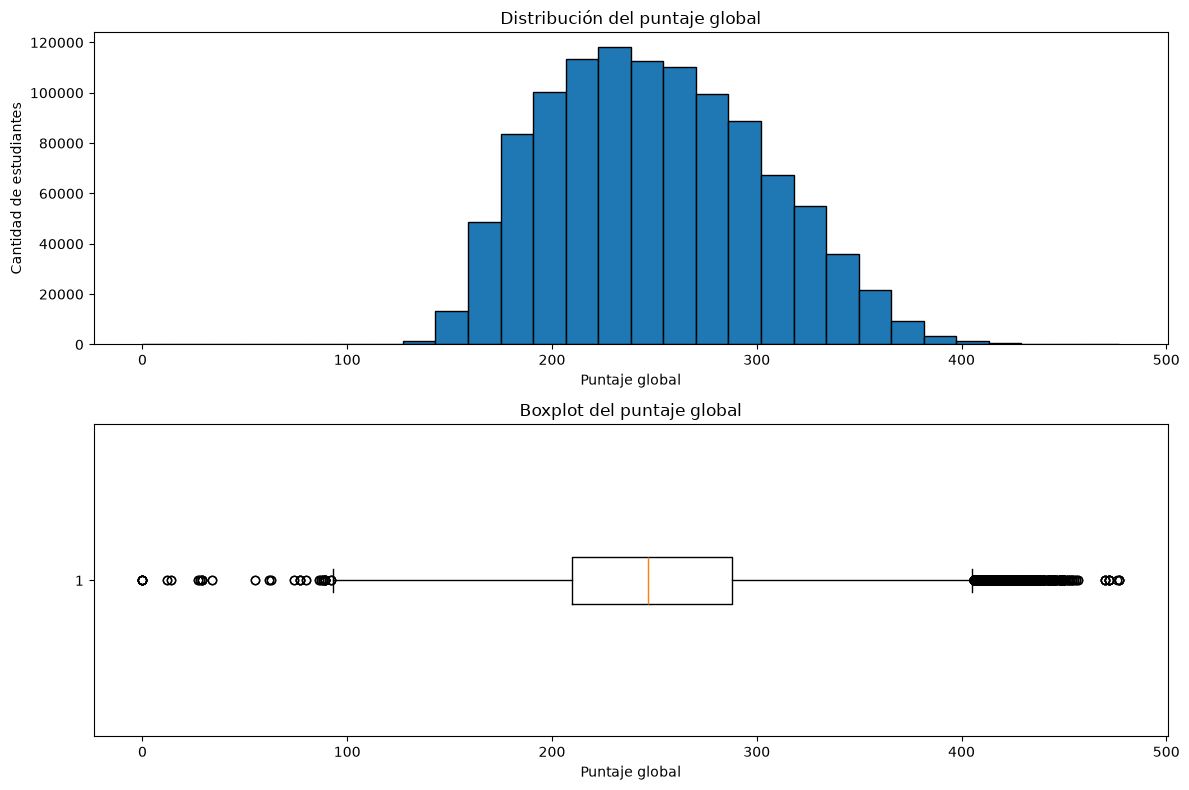

In [10]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)

plt.hist(
    df_limpio["PUNT_GLOBAL"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución del puntaje global")
plt.xlabel("Puntaje global")
plt.ylabel("Cantidad de estudiantes")

plt.subplot(2, 1, 2)

plt.boxplot(
    df_limpio["PUNT_GLOBAL"],
    vert=False
)

plt.title("Boxplot del puntaje global")
plt.xlabel("Puntaje global")

plt.tight_layout()

plt.show()

<Figure size 1000x500 with 0 Axes>

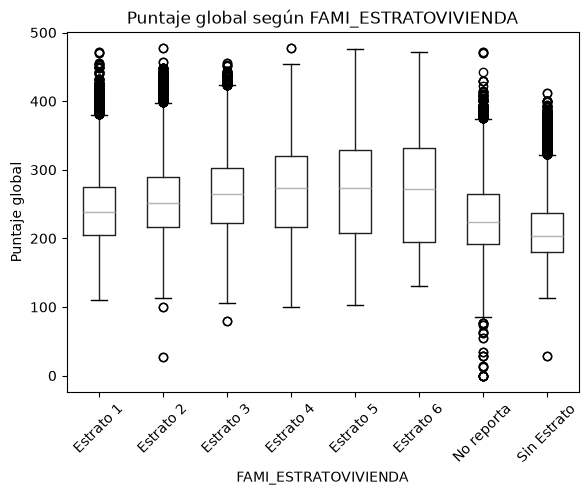

<Figure size 1000x500 with 0 Axes>

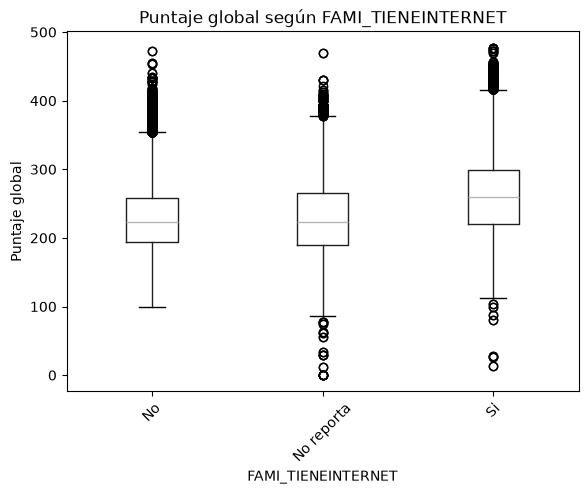

<Figure size 1000x500 with 0 Axes>

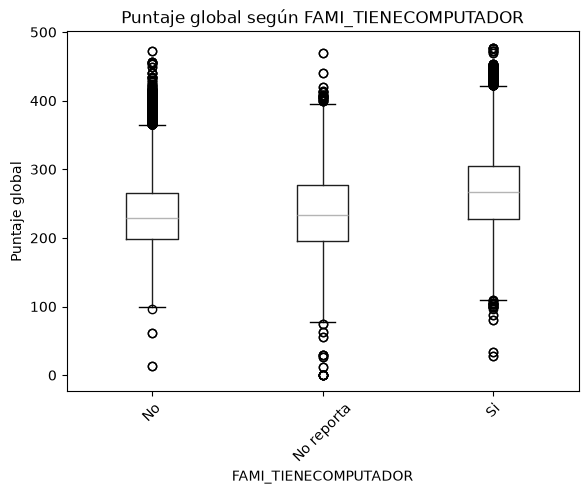

<Figure size 1000x500 with 0 Axes>

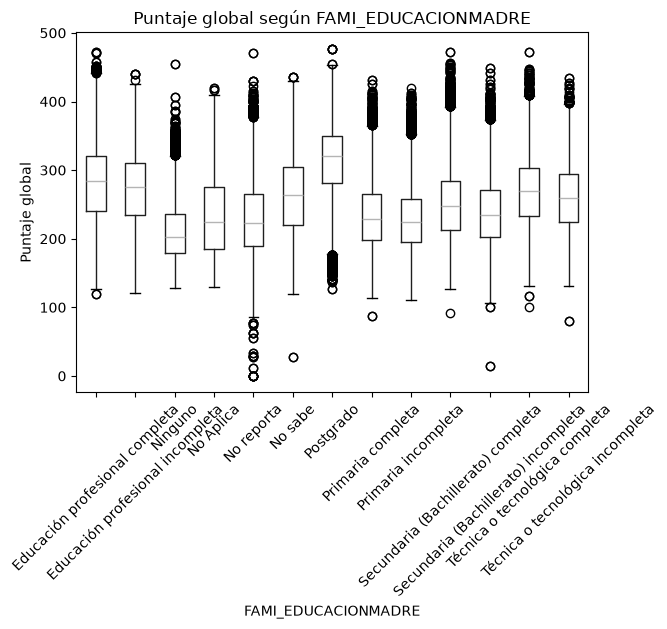

<Figure size 1000x500 with 0 Axes>

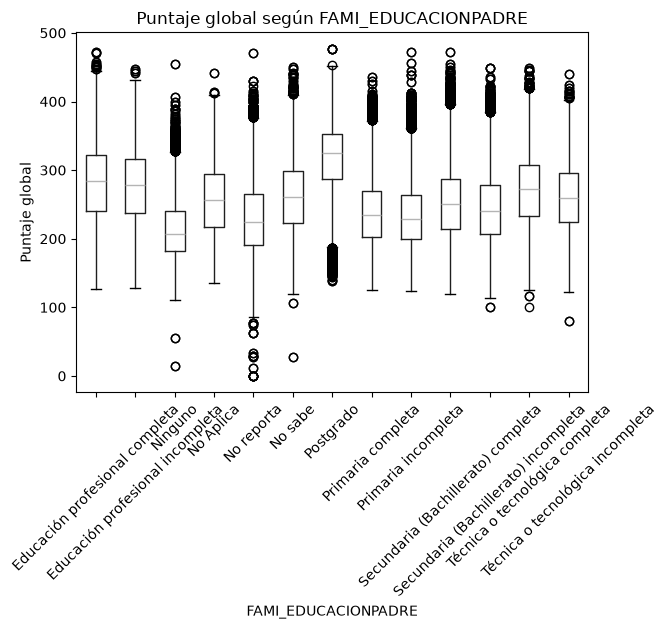

<Figure size 1000x500 with 0 Axes>

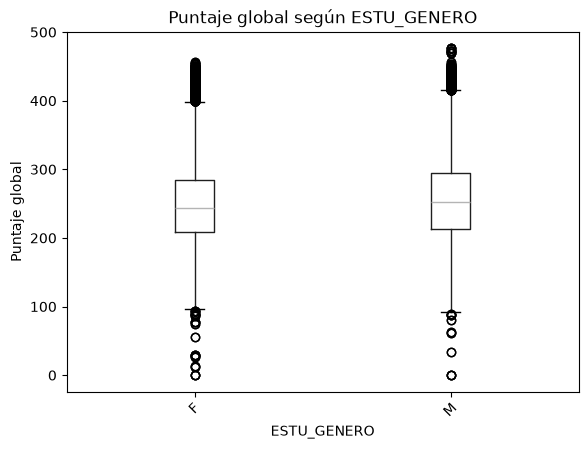

<Figure size 1000x500 with 0 Axes>

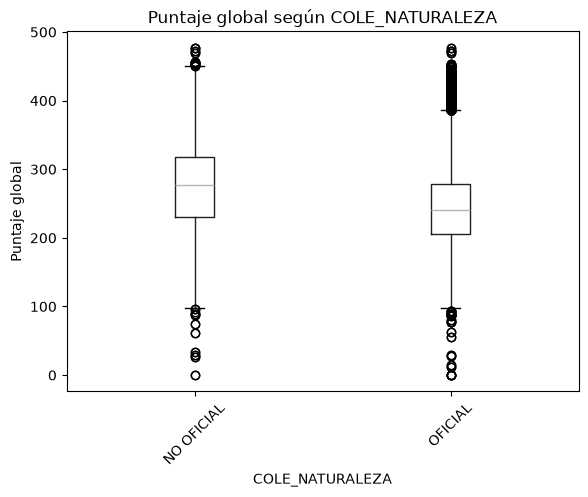

<Figure size 1000x500 with 0 Axes>

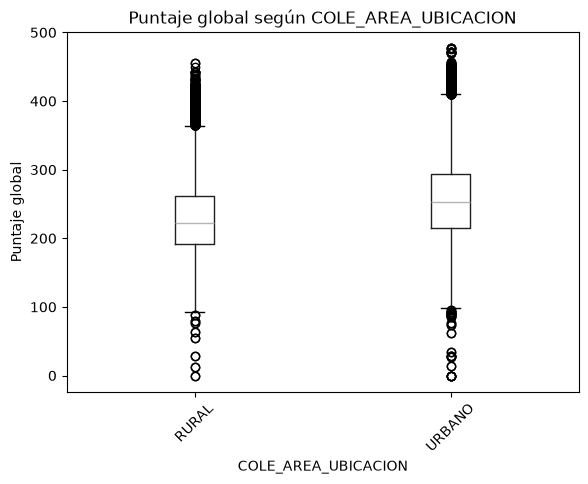

<Figure size 1000x500 with 0 Axes>

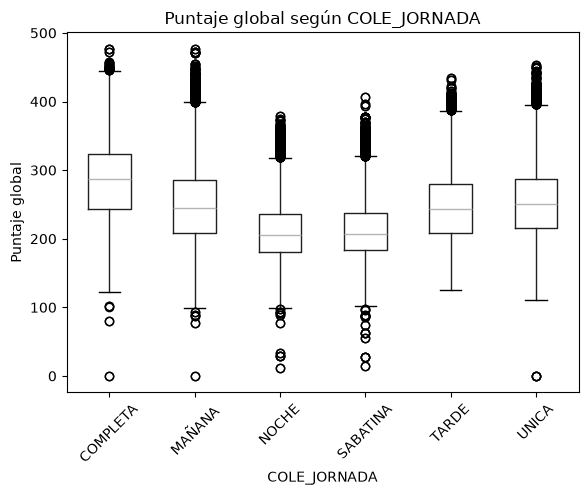

<Figure size 1000x500 with 0 Axes>

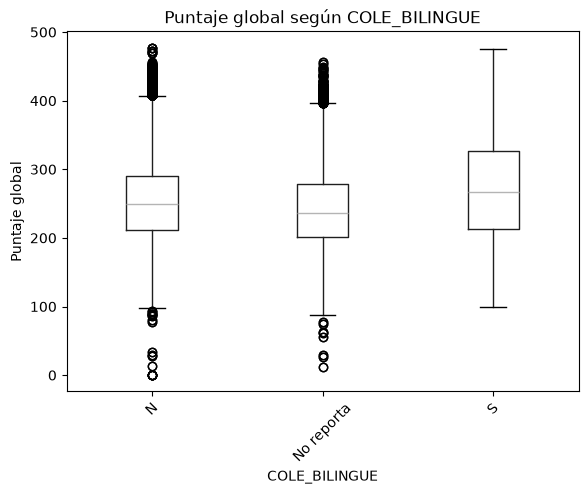

In [11]:
variables = [
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "ESTU_GENERO",
    "COLE_NATURALEZA",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "COLE_BILINGUE",
]

for variable in variables:

    plt.figure(figsize=(10, 5))

    df_limpio.boxplot(
        column="PUNT_GLOBAL",
        by=variable,
        rot=45,
        grid=False
    )

    plt.title(f"Puntaje global según {variable}")
    plt.suptitle("")
    plt.xlabel(variable)
    plt.ylabel("Puntaje global")

    plt.show()

In [12]:
variables_analisis = [
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "ESTU_GENERO",
    "COLE_NATURALEZA",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "COLE_BILINGUE"
]

for variable in variables_analisis:
    print(f"\n{'='*60}")
    print(variable)
    print(df_limpio.groupby(variable)["PUNT_GLOBAL"].mean().round(2))


FAMI_ESTRATOVIVIENDA
FAMI_ESTRATOVIVIENDA
Estrato 1      241.91
Estrato 2      253.68
Estrato 3      263.47
Estrato 4      269.79
Estrato 5      270.16
Estrato 6      266.84
No reporta     230.74
Sin Estrato    212.88
Name: PUNT_GLOBAL, dtype: float64

FAMI_TIENEINTERNET
FAMI_TIENEINTERNET
No            228.33
No reporta    229.79
Si            260.92
Name: PUNT_GLOBAL, dtype: float64

FAMI_TIENECOMPUTADOR
FAMI_TIENECOMPUTADOR
No            233.73
No reporta    238.66
Si            266.41
Name: PUNT_GLOBAL, dtype: float64

FAMI_EDUCACIONMADRE
FAMI_EDUCACIONMADRE
Educación profesional completa          279.94
Educación profesional incompleta        272.25
Ninguno                                 211.22
No Aplica                               234.12
No reporta                              230.12
No sabe                                 262.22
Postgrado                               311.09
Primaria completa                       233.38
Primaria incompleta                     228.80
Secunda

Preguntas guía:

* ¿Hay patrones de interés en las distribuciones de las variables o en las relaciones entre ellas?
* ¿Consideras que existe algún impacto significativo de variables sociodemográficas en los puntajes globales o por área?
* ¿Sobre cuáles variables harías un análisis más profundo?

1)
- La mayor concentración de estudiantes se encuentra entre 200 y 300 puntos, con un pico alrededor de los 240-260 puntos.

- El histograma presenta un solo pico principal (unimodal).

Eso significa que no se observan dos poblaciones claramente separadas (por ejemplo, un grupo con puntajes muy bajos y otro con puntajes muy altos).

- Hay algunos estudiantes con puntajes muy altos (350-430 aproximadamente), pero son pocos comparados con la mayoría.


2)
- Los resultados muestran que las variables relacionadas con las condiciones socioeconómicas y el contexto educativo presentan las mayores diferencias en el puntaje global. En particular, el nivel educativo de los padres, el estrato de la vivienda, el acceso a internet, la disponibilidad de computador y las características del colegio (naturaleza, área de ubicación, jornada y bilingüismo) evidencian asociaciones claras con el desempeño de los estudiantes. En contraste, variables como el género muestran diferencias mucho menores.


## Fase 3: abordar relación variables-desempeño a través de un modelo

En esta fase propondrás, implementarás y reportarás el desempeño de uno o más modelos (al menos uno predictivo) que busquen explicar las relaciones entre factores sociodemográficos y el desempeño en la prueba. Además, concluirás con respecto a la validez de al menos un modelo y los posibles hallazgos que se podrían reportar para el *stakeholder*.

Pautas generales:

* Seleccionar variables y proponer modelos acordes a estas y al contexto del problema.
* Utilizar librerías especializadas (ej., `statsmodels`, `sklearn`, etc.) para indagar sobre los aspectos que contribuyen al éxito de los estudiantes. Los módulos correspondientes a regresión lineal y regresión logística pueden ser útiles.
* Asegurar el cumplimiento de los supuestos y buenas prácticas de cada modelo.
* Utilizar las métricas de evaluación de desempeño (disponibles en las librerías especilizadas), para concluir sobre la validez de los modelos propuestos.

Preguntas guía:

* ¿Existe algún sub-conjunto de variables socio-demográficas que explique razonablemente bien el desempeño de los estudiantes en la prueba?

========== RESULTADOS DEL MODELO ==========

MAE : 36.16
RMSE: 44.43
R²  : 0.2784

========== VARIABLES MÁS INFLUYENTES ==========

                                   Variable  Coeficiente
40                    COLE_JORNADA_SABATINA   -48.261988
39                       COLE_JORNADA_NOCHE   -47.900137
12              FAMI_EDUCACIONMADRE_Ninguno   -25.600514
13            FAMI_EDUCACIONMADRE_No Aplica   -23.254185
24              FAMI_EDUCACIONPADRE_Ninguno   -22.052076
6          FAMI_ESTRATOVIVIENDA_Sin Estrato   -20.583253
28            FAMI_EDUCACIONPADRE_Postgrado    19.614612
41                       COLE_JORNADA_TARDE   -19.548801
18  FAMI_EDUCACIONMADRE_Primaria incompleta   -18.520766
17    FAMI_EDUCACIONMADRE_Primaria completa   -17.253363


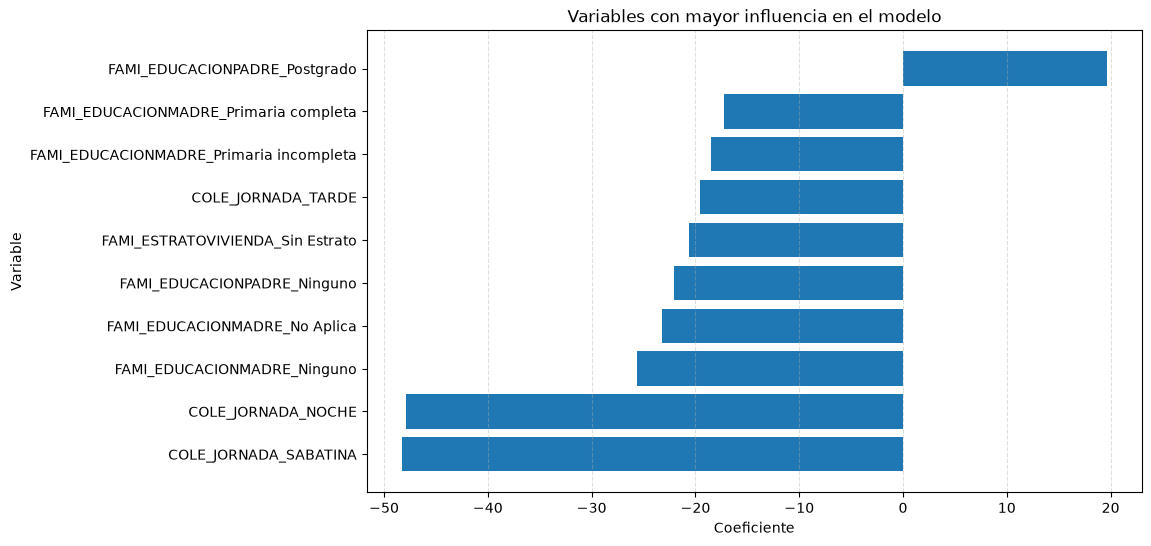

In [13]:
# Implementa tu respuesta en esta celda
modelo_df = df_limpio[
    [
        "PUNT_GLOBAL",
        "FAMI_ESTRATOVIVIENDA",
        "FAMI_TIENEINTERNET",
        "FAMI_TIENECOMPUTADOR",
        "FAMI_EDUCACIONMADRE",
        "FAMI_EDUCACIONPADRE",
        "ESTU_GENERO",
        "COLE_NATURALEZA",
        "COLE_AREA_UBICACION",
        "COLE_JORNADA",
        "COLE_BILINGUE"
    ]
].copy()

# ============================
# 2. Convertir variables categóricas a numéricas
# ============================

modelo_df = pd.get_dummies(
    modelo_df,
    drop_first=True
)

# ============================
# 3. Definir variables X e y
# ============================

X = modelo_df.drop("PUNT_GLOBAL", axis=1)

y = modelo_df["PUNT_GLOBAL"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0
)

modelo = LinearRegression()

modelo.fit(X_train, y_train)


y_pred = modelo.predict(X_test)

# ============================
# 7. Evaluar el modelo
# ============================

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("========== RESULTADOS DEL MODELO ==========\n")

print(f"MAE : {mae:.2f}")

print(f"RMSE: {rmse:.2f}")

print(f"R²  : {r2:.4f}")

# ============================
# 8. Importancia de variables
# ============================

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

coeficientes = coeficientes.reindex(
    coeficientes["Coeficiente"].abs().sort_values(ascending=False).index
)

print("\n========== VARIABLES MÁS INFLUYENTES ==========\n")

print(coeficientes.head(10))

top_coef = coeficientes.head(10).sort_values("Coeficiente")

plt.figure(figsize=(10,6))

plt.barh(top_coef["Variable"], top_coef["Coeficiente"])

plt.title("Variables con mayor influencia en el modelo")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.show()

Se construyó un modelo de regresión lineal utilizando variables sociodemográficas y características del colegio para predecir el puntaje global de los estudiantes. El modelo fue evaluado mediante las métricas MAE, RMSE y R², lo que permitió medir su capacidad predictiva. Además, el análisis de los coeficientes mostró que variables como la jornada del colegio y el nivel educativo de los padres presentan una influencia importante sobre el desempeño académico. Esto indica que existe un conjunto de variables sociodemográficas que contribuyen a explicar, al menos parcialmente, el puntaje obtenido en la prueba Saber 11.

## Fase 4

Deberás elegir y realizar una de las dos alternativas que se encuentran a continuación.

### Alternativa 1: desarrollar una herramienta interactiva de análisis

En esta fase desarrollarás, a partir de alguno de los análisis realizados, una herramienta interactiva que sea relevante en el contexto del problema, acompañada de las instrucciones necesarias para que un usuario la pueda utilizar.

Pautas generales:

* Seleccionar uno de los análisis previos que pueda verse enriquecido con alguna característica de interactividad.
* Seleccionar el/los parámetro(s) que el usuario podrá cambiar.
* Desarrollar las funciones que se deben ejecutar con cada acción del usuario.
* Utilizar una librería especializada (ej., `ipywidgets`, `panel`, etc.) para implementar la herramienta.

Preguntas guía:

* ¿Cuál o cuáles preguntas podrá hacerle el usuario a la herramienta y cómo aporta la respuesta al análisis?
* ¿Qué aprendizajes clave puede explorar u obtener el usuario con esta herramienta?


Estrato de tu vivienda
1. Estrato 1
2. Estrato 2
3. Estrato 3
4. Estrato 4
5. Estrato 5
6. Estrato 6
7. No reporta
8. Sin Estrato

Puntaje esperado hasta este momento:
274.8


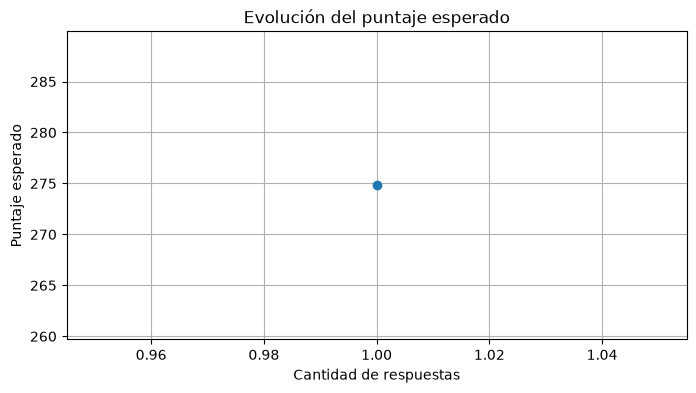


¿Tienes internet en tu hogar?
1. No
2. No reporta
3. Si

Puntaje esperado hasta este momento:
274.8


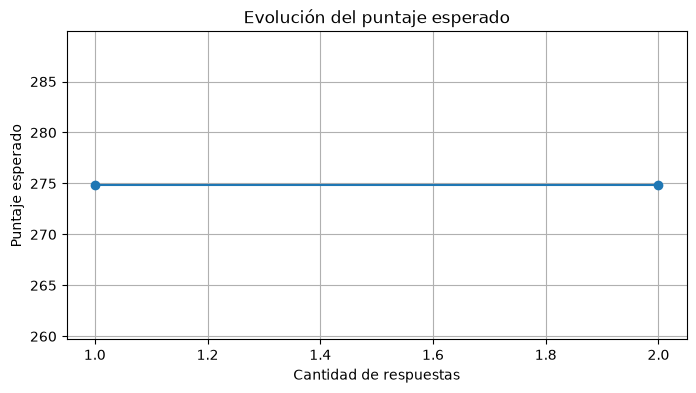


¿Tienes computador en tu hogar?
1. No
2. No reporta
3. Si

Puntaje esperado hasta este momento:
274.8


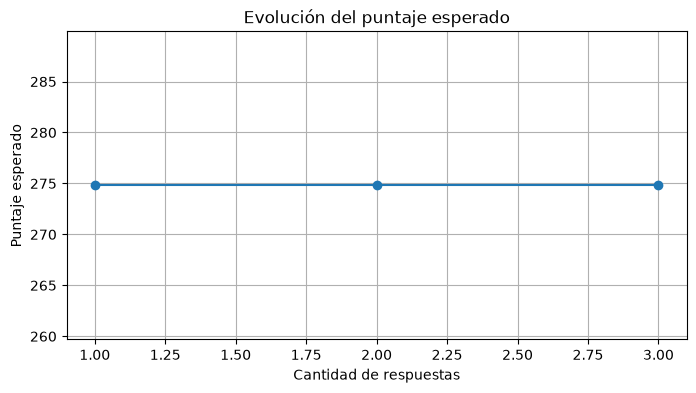


Nivel educativo de tu madre
1. Educación profesional completa
2. Educación profesional incompleta
3. Ninguno
4. No Aplica
5. No reporta
6. No sabe
7. Postgrado
8. Primaria completa
9. Primaria incompleta
10. Secundaria (Bachillerato) completa
11. Secundaria (Bachillerato) incompleta
12. Técnica o tecnológica completa
13. Técnica o tecnológica incompleta

Puntaje esperado hasta este momento:
261.38


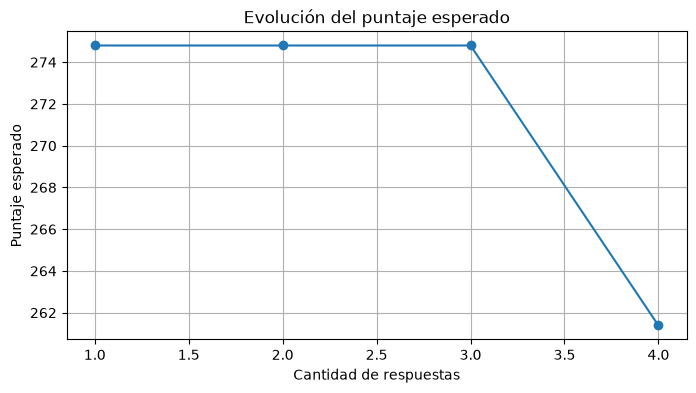


Nivel educativo de tu padre
1. Educación profesional completa
2. Educación profesional incompleta
3. Ninguno
4. No Aplica
5. No reporta
6. No sabe
7. Postgrado
8. Primaria completa
9. Primaria incompleta
10. Secundaria (Bachillerato) completa
11. Secundaria (Bachillerato) incompleta
12. Técnica o tecnológica completa
13. Técnica o tecnológica incompleta

Puntaje esperado hasta este momento:
252.8


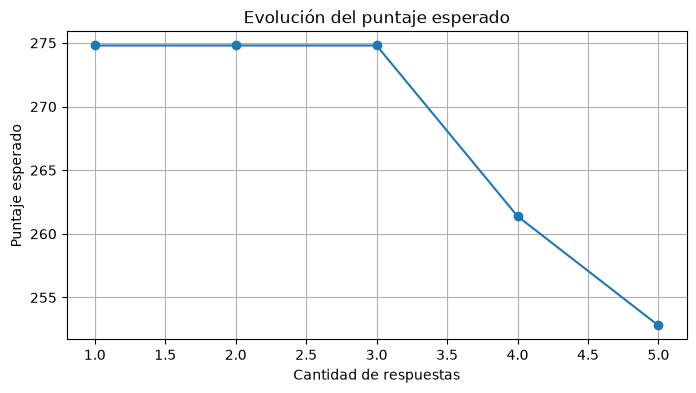


Naturaleza del colegio
1. NO OFICIAL
2. OFICIAL

Puntaje esperado hasta este momento:
240.46


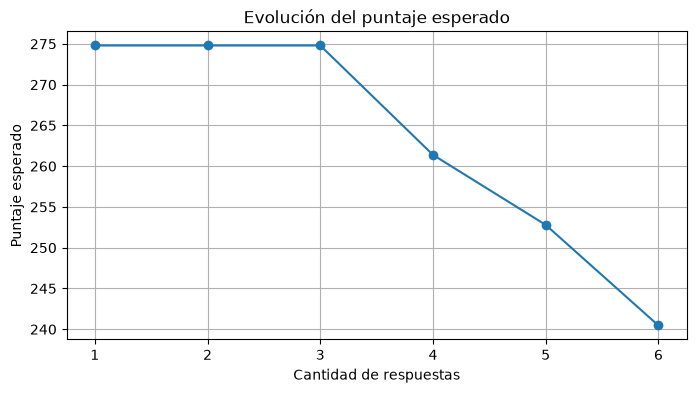


Ubicación del colegio
1. RURAL
2. URBANO

Puntaje esperado hasta este momento:
240.46


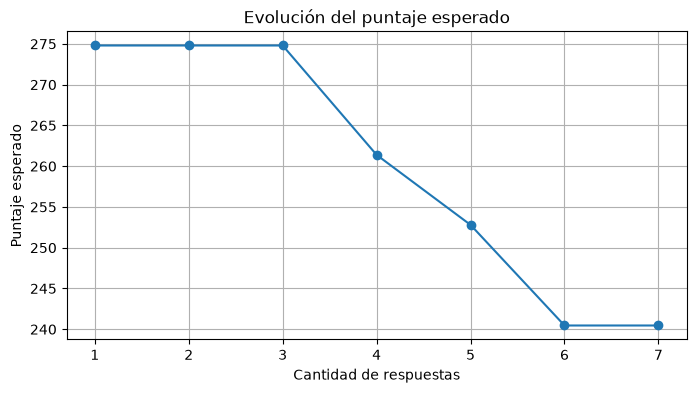


Jornada del colegio
1. COMPLETA
2. MAÑANA
3. NOCHE
4. SABATINA
5. TARDE
6. UNICA

Puntaje esperado hasta este momento:
192.56


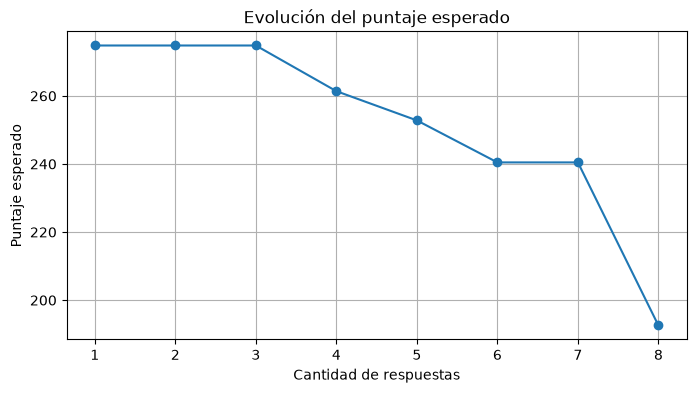


¿Tu colegio es bilingüe?
1. N
2. No reporta
3. S

Puntaje esperado hasta este momento:
192.56


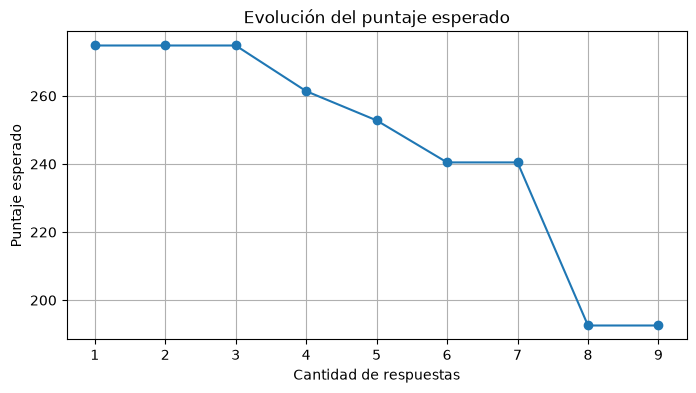


RESULTADO FINAL
FAMI_ESTRATOVIVIENDA: Estrato 1
FAMI_TIENEINTERNET: No
FAMI_TIENECOMPUTADOR: No
FAMI_EDUCACIONMADRE: No reporta
FAMI_EDUCACIONPADRE: No reporta
COLE_NATURALEZA: OFICIAL
COLE_AREA_UBICACION: RURAL
COLE_JORNADA: NOCHE
COLE_BILINGUE: N

PUNTAJE ESPERADO SEGÚN TU PERFIL SOCIODEMOGRÁFICO

192.56 puntos

Promedio nacional del puntaje global:
250.79 puntos

Tu perfil se encuentra aproximadamente 58.23 puntos por debajo del promedio nacional.

Clasificación del perfil:
Muy por debajo del promedio nacional.

IMPORTANTE:

Este resultado NO representa el puntaje real que obtendrá un estudiante
en la prueba Saber 11.

Se trata de una estimación basada en los patrones encontrados en más de
un millón de registros del ICFES y en las variables sociodemográficas
seleccionadas durante el análisis.

La herramienta permite identificar qué características suelen estar
asociadas con desempeños más altos o más bajos en la prueba, pero no
considera factores individuales como hábitos de estudi

In [20]:
variables = [
    ("FAMI_ESTRATOVIVIENDA", "Estrato de tu vivienda"),
    ("FAMI_TIENEINTERNET", "¿Tienes internet en tu hogar?"),
    ("FAMI_TIENECOMPUTADOR", "¿Tienes computador en tu hogar?"),
    ("FAMI_EDUCACIONMADRE", "Nivel educativo de tu madre"),
    ("FAMI_EDUCACIONPADRE", "Nivel educativo de tu padre"),
    ("COLE_NATURALEZA", "Naturaleza del colegio"),
    ("COLE_AREA_UBICACION", "Ubicación del colegio"),
    ("COLE_JORNADA", "Jornada del colegio"),
    ("COLE_BILINGUE", "¿Tu colegio es bilingüe?")
]

perfil_usuario = {}
puntajes = []

for columna, pregunta in variables:

    opciones = sorted(df_limpio[columna].unique())

    print("\n" + "=" * 60)
    print(pregunta)
    print("=" * 60)

    for i, opcion in enumerate(opciones):
        print(f"{i + 1}. {opcion}")

    seleccion = int(input("\nSeleccione una opción: "))
    respuesta = opciones[seleccion - 1]

    perfil_usuario[columna] = respuesta

    fila = {}

    for variable in X.columns:
        fila[variable] = 0

    for variable_original, valor in perfil_usuario.items():

        if variable_original in X.columns:
            fila[variable_original] = valor

        else:
            nombre_dummy = f"{variable_original}_{valor}"

            if nombre_dummy in X.columns:
                fila[nombre_dummy] = 1

    nuevo_estudiante = pd.DataFrame([fila])

    puntaje_predicho = modelo.predict(nuevo_estudiante)[0]

    puntajes.append(puntaje_predicho)

    print("\nPuntaje esperado hasta este momento:")
    print(round(puntaje_predicho, 2))

    plt.figure(figsize=(8, 4))

    plt.plot(
        range(1, len(puntajes) + 1),
        puntajes,
        marker="o"
    )

    plt.title("Evolución del puntaje esperado")
    plt.xlabel("Cantidad de respuestas")
    plt.ylabel("Puntaje esperado")
    plt.grid(True)

    plt.show()


print("\n" + "=" * 60)
print("RESULTADO FINAL")
print("=" * 60)

for variable, valor in perfil_usuario.items():
    print(f"{variable}: {valor}")

puntaje_final = round(puntajes[-1], 2)

print("\n" + "=" * 60)
print("PUNTAJE ESPERADO SEGÚN TU PERFIL SOCIODEMOGRÁFICO")
print("=" * 60)

print(f"\n{puntaje_final} puntos")

promedio_nacional = 250.79

print("\nPromedio nacional del puntaje global:")
print(f"{promedio_nacional} puntos")

diferencia = round(puntaje_final - promedio_nacional, 2)

if diferencia >= 0:
    print(
        f"\nTu perfil se encuentra aproximadamente {diferencia} puntos por encima del promedio nacional."
    )
else:
    print(
        f"\nTu perfil se encuentra aproximadamente {abs(diferencia)} puntos por debajo del promedio nacional."
    )

if puntaje_final < 230:
    nivel = "Muy por debajo del promedio nacional."

elif puntaje_final < 270:
    nivel = "Cercano al promedio nacional."

elif puntaje_final < 320:
    nivel = "Superior al promedio nacional."

else:
    nivel = "Muy superior al promedio nacional."

print("\nClasificación del perfil:")
print(nivel)

print("\nIMPORTANTE:")
print("""
Este resultado NO representa el puntaje real que obtendrá un estudiante
en la prueba Saber 11.

Se trata de una estimación basada en los patrones encontrados en más de
un millón de registros del ICFES y en las variables sociodemográficas
seleccionadas durante el análisis.

La herramienta permite identificar qué características suelen estar
asociadas con desempeños más altos o más bajos en la prueba, pero no
considera factores individuales como hábitos de estudio, habilidades
académicas o preparación específica para el examen.
""")

## Referencias

*  J. VanderPlas (2016) *Python Data Science Handbook: Essential Tools for Working with Data* O'Reilly Media, Inc.
*  scikit-learn developers . (2020). Demo of DBSCAN clustering algorithm. 11 Diciembre 2020, de scikit-learn <br> https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py